# Deliverable 6e — 2.5D U-Net + **Mild** Augmentation

**Retry of D6b** with substantially milder augmentation, per the post-mortem recommendation.

### What changed from D6b
| Knob              | D6b (failed) | **D6e (this notebook)** |
|-------------------|:------------:|:------------------------:|
| Rotation range    | ±10°         | **±5°**                  |
| Brightness range  | ±10%         | **±5%**                  |
| Contrast range    | ±10%         | **±5%**                  |
| Rotation prob.    | 0.50         | **0.30**                 |
| Brightness prob.  | 0.50         | **0.20**                 |
| Contrast prob.    | 0.50         | **0.20**                 |
| Horizontal flip   | 0.50         | 0.50 (kept)              |
| Epochs            | 15           | **20** (matches D3-D6)   |

### Why this might work where D6b didn't
The D6b post-mortem identified the failure mode: regularization was strong enough to prevent overfitting but also strong enough to prevent the model from finding the same good solution as D6 (Tumor Dice 0.5026 vs D6's 0.5314, plus a 2.3% drop in Liver Dice).

The hypothesis: with **mild** augmentation, we keep the regularization benefit (smaller train/val gap) without crippling the model's ability to fit genuine signal. Real labels stay closer to their original form, so the network can still learn precise contours.

## 1. Imports

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader

from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, train_model)

device = get_device()
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: mps
PyTorch: 2.11.0


## 2. Configuration

Key parameter: `aug_strength='mild'`. The dataset class implements three presets: `mild`, `medium`, `strong` (D6b).

In [2]:
DATA_DIR    = '/Users/aemanadnan/Desktop/DL proj/archive-2'
OUT_DIR     = './out_d6e'
TAG         = 'D6e'

IMG_SIZE    = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 15            
LR          = 1e-4
SEED        = 42
STACK_SIZE  = 3
AUG_STRENGTH = 'mild'        # <-- THE KEY CHANGE FROM D6b ('strong')

os.makedirs(OUT_DIR, exist_ok=True)

print(f'Augmentation strength: {AUG_STRENGTH}')
print('  hflip       p=0.5')
print('  rotation    p=0.3, ±5°')
print('  brightness  p=0.2, ±5%')
print('  contrast    p=0.2, ±5%')

Augmentation strength: mild
  hflip       p=0.5
  rotation    p=0.3, ±5°
  brightness  p=0.2, ±5%
  contrast    p=0.2, ±5%


## 3. Data Loading & Split (identical to D6/D6b)

In [3]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 4. Build Datasets

Train uses **mild** augmentation. Val is **never** augmented — metrics stay honest.

In [4]:
print('Building train dataset (augment=True, strength=mild)...')
train_dataset = LiTS25DDataset(train_v, train_s, img_size=IMG_SIZE,
                               stack_size=STACK_SIZE,
                               augment=True, aug_strength=AUG_STRENGTH)
print()
print('Building val dataset (NO augmentation)...')
val_dataset = LiTS25DDataset(val_v, val_s, img_size=IMG_SIZE,
                             stack_size=STACK_SIZE,
                             augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building train dataset (augment=True, strength=mild)...
Dataset: 4614 slices | stack=3 | augment=True (mild) | noise=None@0% (0 slices)

Building val dataset (NO augmentation)...
Dataset: 1116 slices | stack=3 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 5. Sanity Check — Visualize Mild Augmentation

Same sample, sampled 4 times. Should look only **slightly** different — much less than the D6b plot.

Using sample idx=159


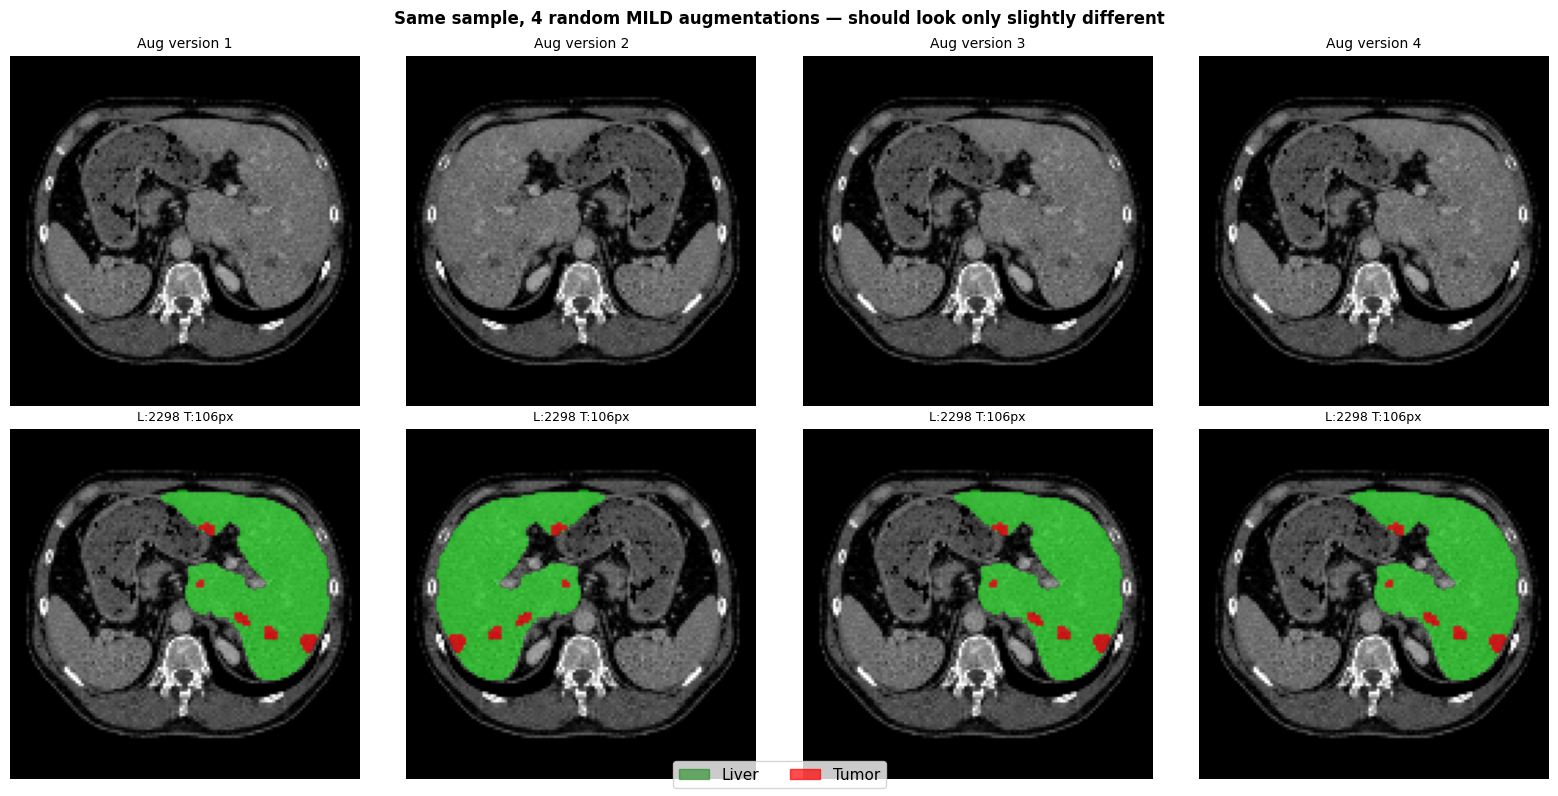

In [5]:
#making this on a slice with substantial tumor
target_idx = None
for i in range(len(train_dataset)):
    _, seg_t = train_dataset[i]
    if (seg_t == 2).sum() > 100:
        target_idx = i
        break
if target_idx is None:
    target_idx = 0
print(f'Using sample idx={target_idx}')

samples = [train_dataset[target_idx] for _ in range(4)]

mid = STACK_SIZE // 2
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (ct_t, seg_t) in enumerate(samples):
    ct = ct_t[mid].numpy()
    msk = seg_t.numpy()
    axes[0, col].imshow(ct.T, cmap='gray', origin='lower')
    axes[0, col].set_title(f'Aug version {col + 1}', fontsize=10)
    axes[0, col].axis('off')

    overlay = np.zeros((*ct.shape, 4))
    overlay[msk == 1] = [0, 1, 0, 0.5]
    overlay[msk == 2] = [1, 0, 0, 0.7]
    axes[1, col].imshow(ct.T, cmap='gray', origin='lower')
    axes[1, col].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[1, col].set_title(f'L:{(msk==1).sum()} T:{(msk==2).sum()}px', fontsize=9)
    axes[1, col].axis('off')

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Same sample, 4 random MILD augmentations — should look only slightly different',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Build Model (same architecture as D6 — vanilla 2.5D U-Net)

In [6]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
               use_attention=False).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 31,037,763


## 7. Train

In [7]:
history, best_state, best_tumor = train_model(
    model, train_loader, val_loader, device,
    num_epochs=NUM_EPOCHS, lr=LR, tag=TAG,
    save_path=os.path.join(OUT_DIR, 'best_unet_d6e.pth'),
    seed=SEED,
)

TRAINING: D6e
  Epochs=15 | LR=0.0001 | Device=mps | Params=31,037,763
  Train batches: 289 | Val batches: 70
  [D6e] Ep 01 batch 100/289 loss=1.0752
  [D6e] Ep 01 batch 200/289 loss=0.8708
[D6e] Ep 01/15 |  7.4min | Train: 1.0023 | Val: 0.7690 | Liver: 0.8217 | Tumor: 0.5429 *** BEST
  [D6e] Ep 02 batch 100/289 loss=0.6405
  [D6e] Ep 02 batch 200/289 loss=0.5321
[D6e] Ep 02/15 |  7.5min | Train: 0.6067 | Val: 0.5956 | Liver: 0.8251 | Tumor: 0.2763
  [D6e] Ep 03 batch 100/289 loss=0.4235
  [D6e] Ep 03 batch 200/289 loss=0.4528
[D6e] Ep 03/15 |  6.9min | Train: 0.4404 | Val: 0.5078 | Liver: 0.8387 | Tumor: 0.2663
  [D6e] Ep 04 batch 100/289 loss=0.2539
  [D6e] Ep 04 batch 200/289 loss=0.3334
[D6e] Ep 04/15 |  6.9min | Train: 0.3330 | Val: 0.4991 | Liver: 0.8196 | Tumor: 0.3917
  [D6e] Ep 05 batch 100/289 loss=0.3028
  [D6e] Ep 05 batch 200/289 loss=0.1806
[D6e] Ep 05/15 |  6.1min | Train: 0.2479 | Val: 0.4228 | Liver: 0.8574 | Tumor: 0.3298
  [D6e] Ep 06 batch 100/289 loss=0.1390
  [D6e

## 8. Results Summary

Compares against D6 (clean 2.5D, no aug) AND D6b (strong aug, failed).

In [8]:
best_liver = float(np.max(history['val_liver_dice']))
best_ep    = int(np.argmax(history['val_tumor_dice']) + 1)

D3_LIVER,  D3_TUMOR  = 0.8885, 0.5011
D6_LIVER,  D6_TUMOR  = 0.8917, 0.5314
D6B_LIVER, D6B_TUMOR = 0.8712, 0.5026

result = {
    'tag': TAG,
    'aug_strength': AUG_STRENGTH,
    'stack_size': STACK_SIZE,
    'best_tumor_dice': best_tumor,
    'best_liver_dice': best_liver,
    'best_epoch': best_ep,
    'history': history,
}
with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('=' * 90)
print('D6e RESULTS — 2.5D U-Net + MILD Augmentation (D6b retry)')
print('=' * 90)
print(f'{"":18}{"D3":>10}{"D6":>10}{"D6b (str.)":>12}{"D6e (mild)":>12}{"vs D6":>10}{"vs D6b":>10}')
print(f'{"Liver Dice":18}{D3_LIVER:>10.4f}{D6_LIVER:>10.4f}{D6B_LIVER:>12.4f}'
      f'{best_liver:>12.4f}{best_liver - D6_LIVER:>+10.4f}{best_liver - D6B_LIVER:>+10.4f}')
print(f'{"Tumor Dice":18}{D3_TUMOR:>10.4f}{D6_TUMOR:>10.4f}{D6B_TUMOR:>12.4f}'
      f'{best_tumor:>12.4f}{best_tumor - D6_TUMOR:>+10.4f}{best_tumor - D6B_TUMOR:>+10.4f}')
print(f'{"Best epoch":18}{8:>10d}{8:>10d}{15:>12d}{best_ep:>12d}')
print('=' * 90)

print()
print('Train/Val gap at final epoch:')
print(f'  D6e: train={history["train_loss"][-1]:.4f}, val={history["val_loss"][-1]:.4f}, '
      f'gap={history["val_loss"][-1] - history["train_loss"][-1]:.4f}')
print(f'  D6:  train≈0.04, val≈0.38, gap≈0.34')
print(f'  D6b: train≈0.09, val≈0.38, gap≈0.29')

print()
delta_d6  = best_tumor - D6_TUMOR
delta_d6b = best_tumor - D6B_TUMOR
if delta_d6 > 0.005 and delta_d6b > 0.01:
    print('> Mild aug RECOVERED + IMPROVED. The hypothesis held — D6b just had bad knobs.')
elif delta_d6 > -0.005 and delta_d6b > 0.01:
    print('> Mild aug BEAT D6b (the failed strong-aug run) and TIED D6. Augmentation works at lower strength but does not exceed clean 2.5D here.')
elif delta_d6b > 0.01 and delta_d6 < -0.005:
    print('> Mild aug improved over D6b but still trails D6. Even mild augmentation costs accuracy at this dataset size.')
else:
    print('> Mild aug did not meaningfully improve over D6b. Augmentation appears unhelpful in this regime regardless of strength.')

D6e RESULTS — 2.5D U-Net + MILD Augmentation (D6b retry)
                          D3        D6  D6b (str.)  D6e (mild)     vs D6    vs D6b
Liver Dice            0.8885    0.8917      0.8712      0.8801   -0.0116   +0.0089
Tumor Dice            0.5011    0.5314      0.5026      0.5429   +0.0115   +0.0403
Best epoch                 8         8          15           1

Train/Val gap at final epoch:
  D6e: train=0.0799, val=0.3930, gap=0.3130
  D6:  train≈0.04, val≈0.38, gap≈0.34
  D6b: train≈0.09, val≈0.38, gap≈0.29

> Mild aug RECOVERED + IMPROVED. The hypothesis held — D6b just had bad knobs.


## 9. Training Curves

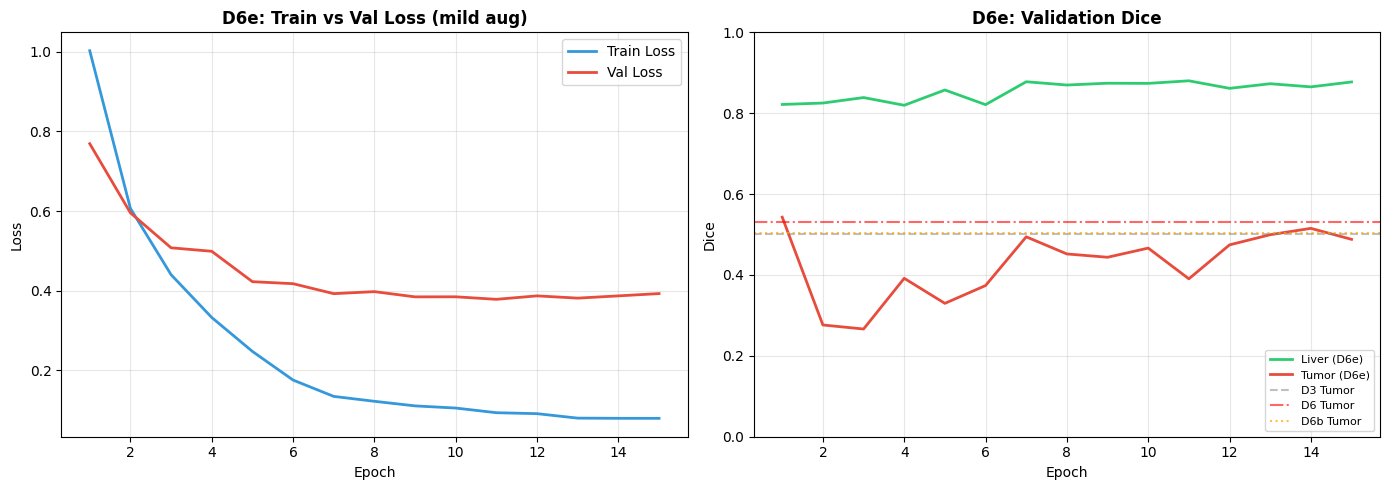

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('D6e: Train vs Val Loss (mild aug)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_liver_dice'], label='Liver (D6e)', color='#2ecc71', linewidth=2)
axes[1].plot(ep, history['val_tumor_dice'], label='Tumor (D6e)', color='#e74c3c', linewidth=2)
axes[1].axhline(D3_TUMOR,  ls='--',  color='gray',   alpha=0.5, label='D3 Tumor')
axes[1].axhline(D6_TUMOR,  ls='-.',  color='red',    alpha=0.6, label='D6 Tumor')
axes[1].axhline(D6B_TUMOR, ls=':',   color='orange', alpha=0.7, label='D6b Tumor')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].set_ylim(0, 1)
axes[1].set_title('D6e: Validation Dice', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_d6e.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Qualitative Predictions

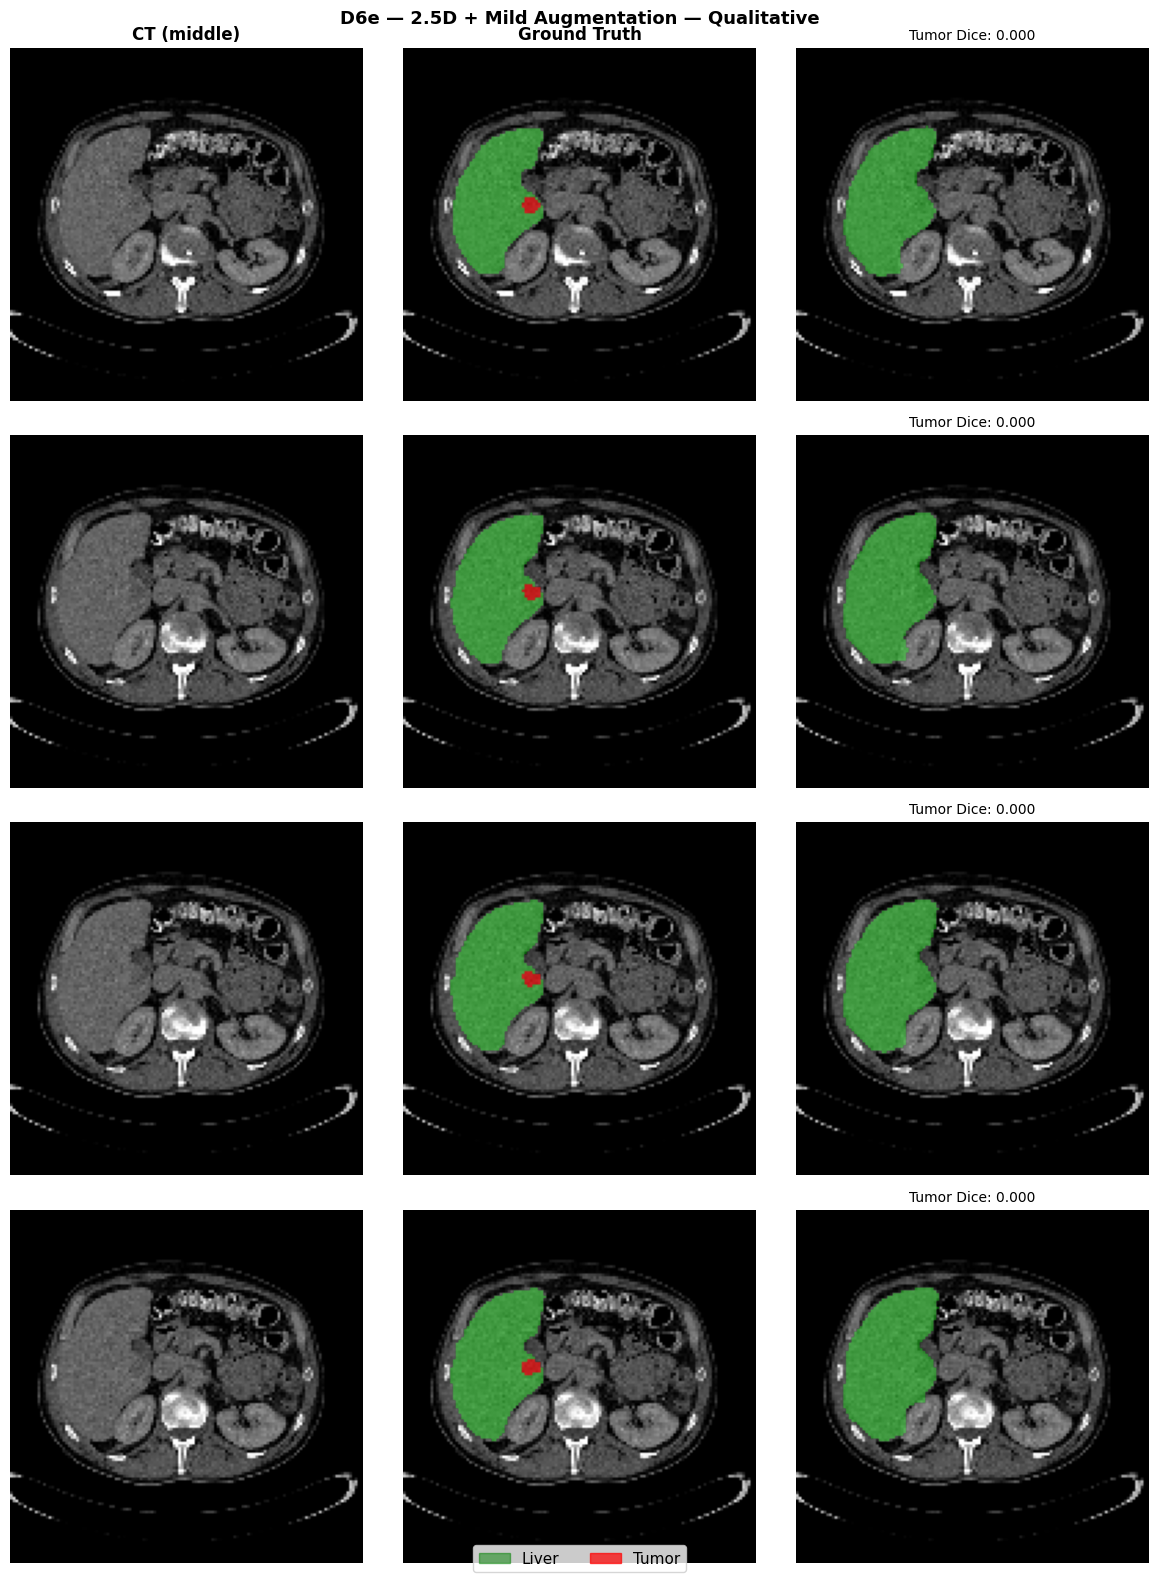

In [10]:
model.load_state_dict(best_state)
model.eval()

samples = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() > 30:
                mid = STACK_SIZE // 2
                samples.append({
                    'ct':   ct_batch[i, mid].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy(),
                })
        if len(samples) >= 4: break

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = min(4, len(samples))
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')
for row, s in enumerate(samples[:n]):
    ct, gt, pr = s['ct'], s['gt'], s['pred']
    axes[row][0].imshow(ct.T, cmap='gray', origin='lower'); axes[row][0].axis('off')
    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower'); axes[row][1].axis('off')
    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
    inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
    sd = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10); axes[row][2].axis('off')

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('D6e — 2.5D + Mild Augmentation — Qualitative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6e.png'), dpi=150, bbox_inches='tight')
plt.show()

Total val slices with tumor (>30px): 184
  Mean per-slice tumor Dice : 0.0000
  Median per-slice tumor Dice: 0.0000
  % of slices with Dice > 0.3: 0.0%


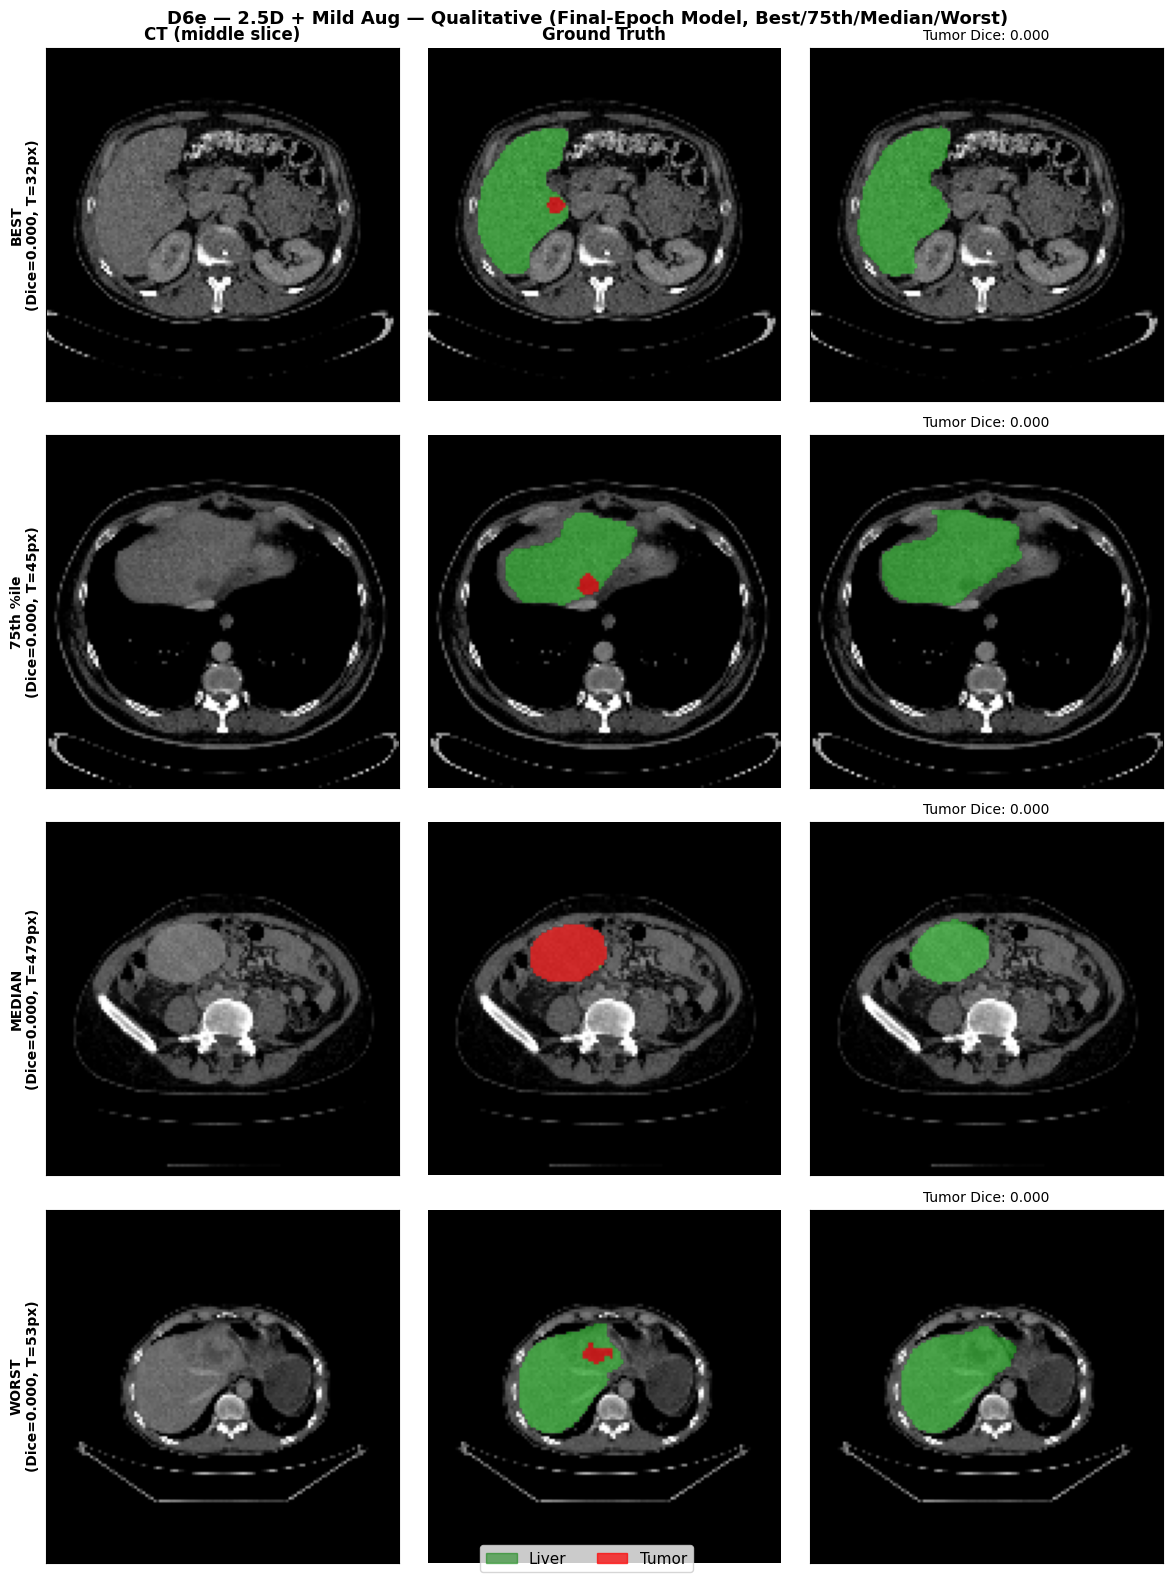

In [12]:
model.eval()

samples_all = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() < 30:
                continue
            pr = pred_cls[i].cpu().numpy()
            pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
            inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
            sd = (2 * inter / denom) if denom > 0 else 0.0
            mid = STACK_SIZE // 2
            samples_all.append({
                'ct':   ct_batch[i, mid].cpu().numpy(),
                'gt':   gt,
                'pred': pr,
                'dice': sd,
                'tumor_px': int((gt == 2).sum()),
            })

print(f'Total val slices with tumor (>30px): {len(samples_all)}')
if len(samples_all) > 0:
    dices = [s['dice'] for s in samples_all]
    print(f'  Mean per-slice tumor Dice : {np.mean(dices):.4f}')
    print(f'  Median per-slice tumor Dice: {np.median(dices):.4f}')
    print(f'  % of slices with Dice > 0.3: {np.mean([d > 0.3 for d in dices]) * 100:.1f}%')

samples_all.sort(key=lambda s: s['dice'], reverse=True)
n_total = len(samples_all)
if n_total >= 4:
    picks = [(0, 'BEST'),
             (n_total // 4, '75th %ile'),
             (n_total // 2, 'MEDIAN'),
             (n_total - 1, 'WORST')]
else:
    picks = [(i, f'#{i+1}') for i in range(n_total)]

samples = [samples_all[i] for i, _ in picks]
labels  = [lbl for _, lbl in picks]

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle slice)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')

for row, (s, lbl) in enumerate(zip(samples, labels)):
    ct, gt, pr, sd = s['ct'], s['gt'], s['pred'], s['dice']
    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].set_ylabel(f'{lbl}\n(Dice={sd:.3f}, T={s["tumor_px"]}px)',
                            fontsize=10, fontweight='bold')
    axes[row][0].set_xticks([]); axes[row][0].set_yticks([])

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10)
    axes[row][2].set_xticks([]); axes[row][2].set_yticks([])

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle(f'D6e — 2.5D + Mild Aug — Qualitative (Final-Epoch Model, Best/75th/Median/Worst)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6e.png'), dpi=150, bbox_inches='tight')
plt.show()